NpzFile 'data/pigment_palette/result_spectra.npz' with keys: ca_zn, mn, hg, wood, cr...


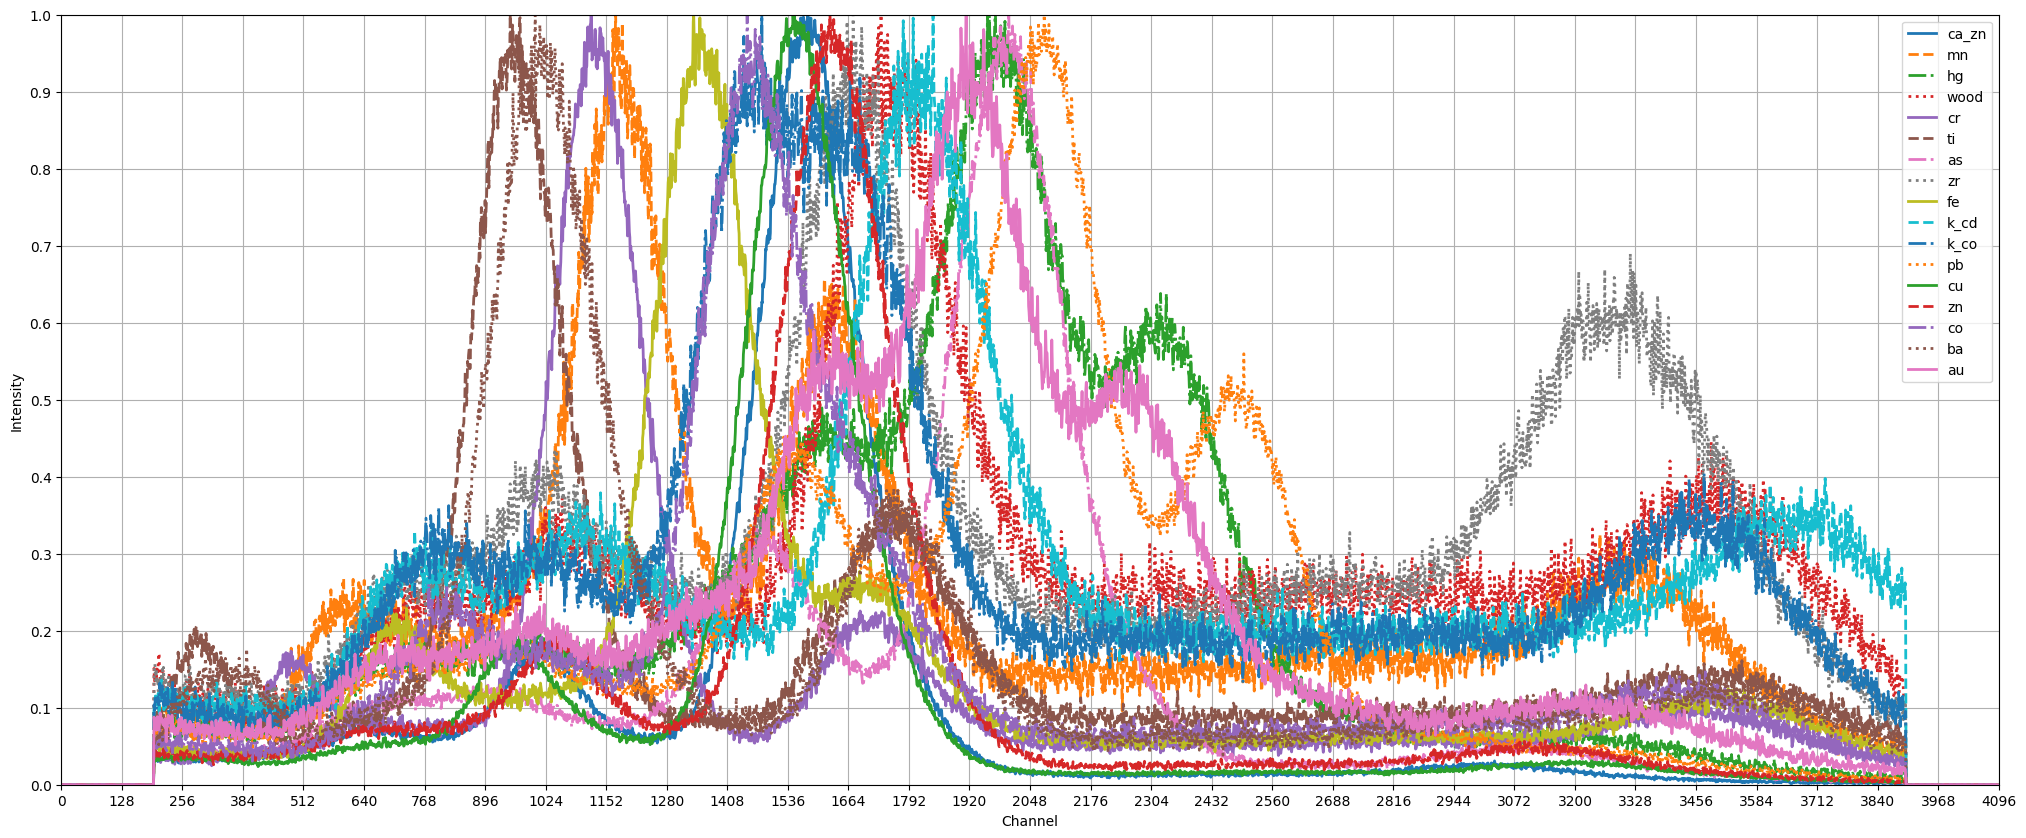

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import itertools

spectra = np.load("data/pigment_palette/result_spectra.npz",allow_pickle=True)
print(spectra)

line_styles = ['-', '--', '-.', ':']
plt.figure(figsize=(25, 10))
for (pad_name, spectrum), linestyle in zip(
    spectra.items(), itertools.cycle(line_styles)
):
    plt.plot(spectrum, linestyle=linestyle, label=pad_name, linewidth=2)
    plt.set_cmap("tab10")


plt.legend()
plt.ylim(0, 1)
plt.xlim(0, len(spectrum))
plt.grid(True)
plt.xticks(np.arange(0, len(spectrum)+1, 128))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel("Channel")
plt.ylabel("Intensity")
plt.show()

/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:249: RuntimeWarning: Performing pixel-wise extrapolation, which can be slow for large images.
  warnings.warn("Performing pixel-wise extrapolation, which can be slow for large images.", RuntimeWarning)


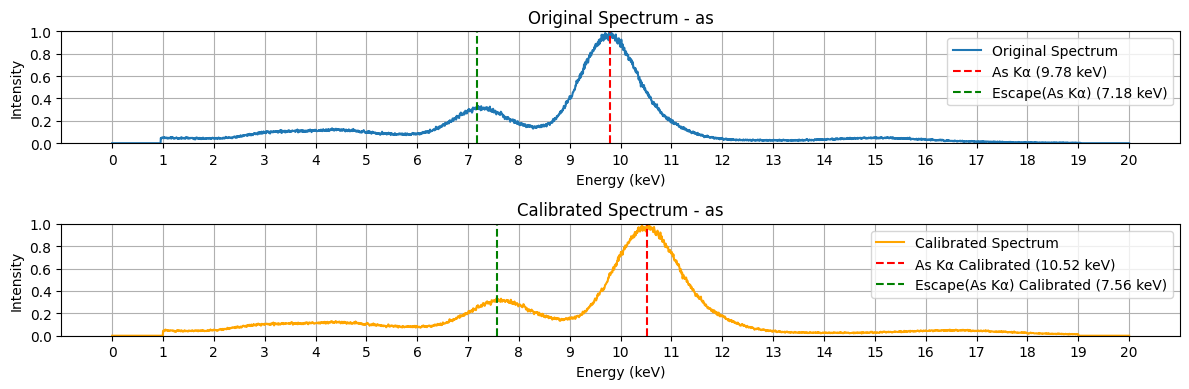

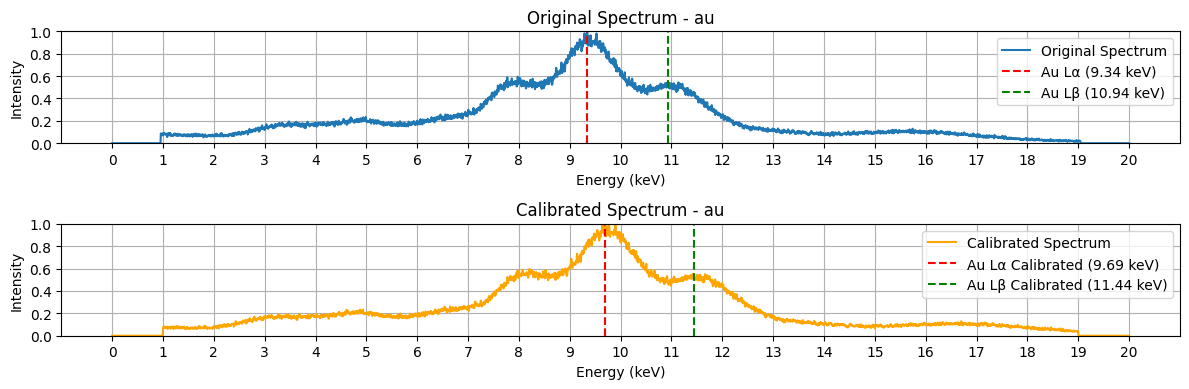

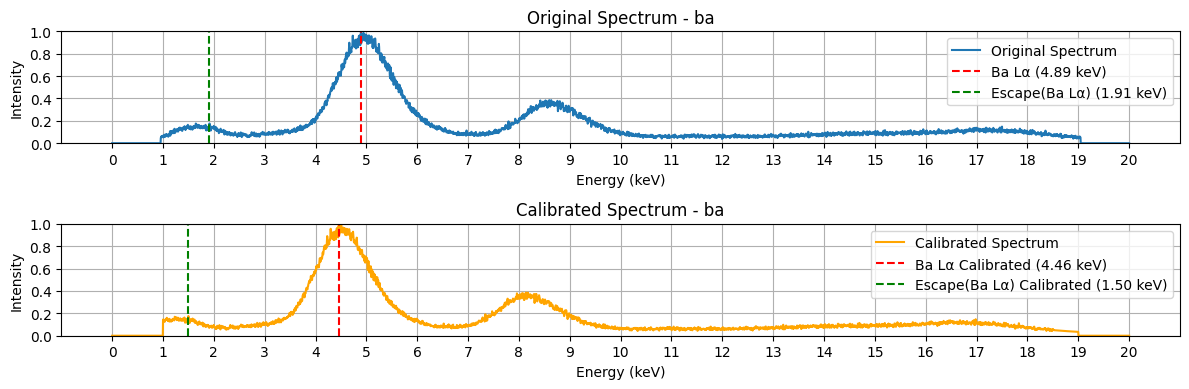

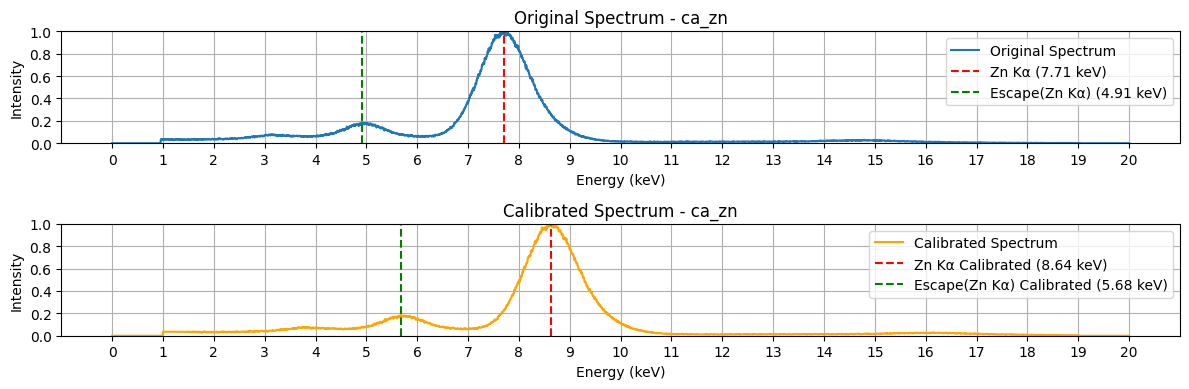

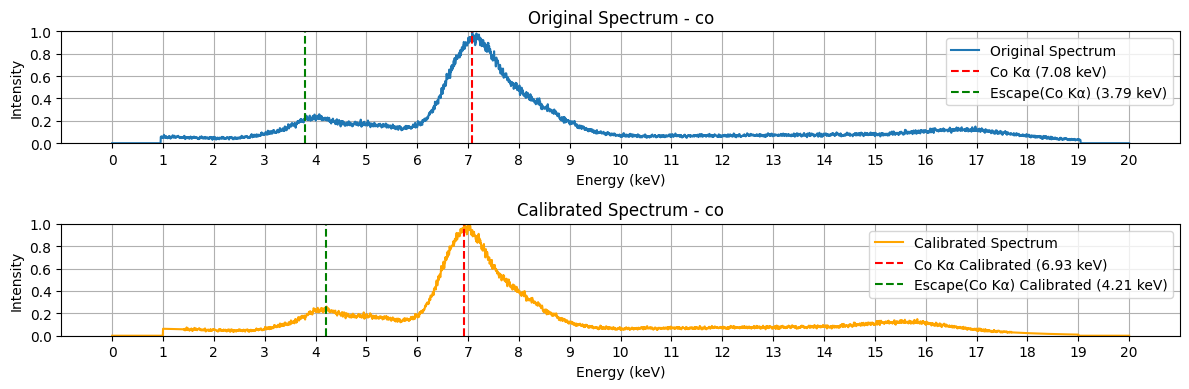

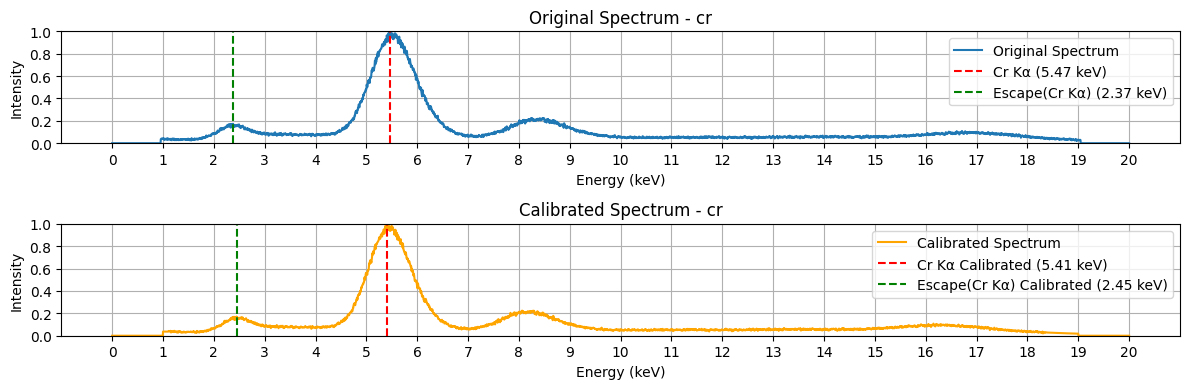

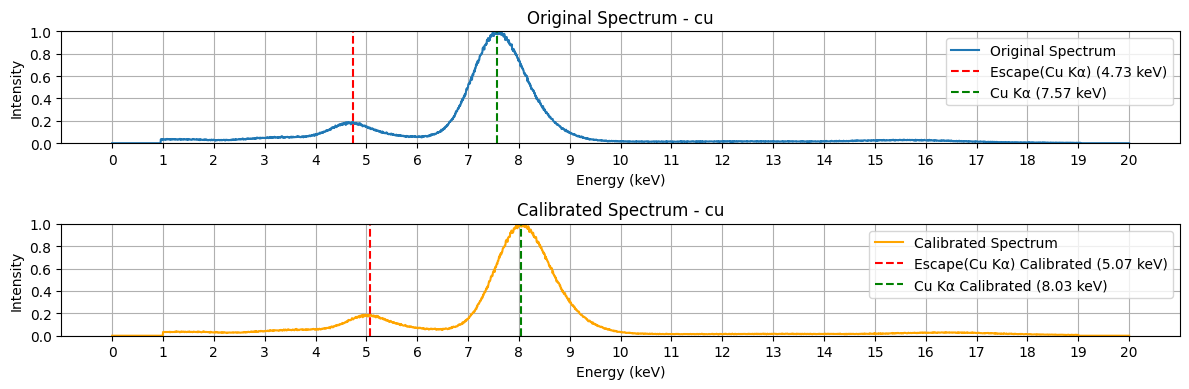

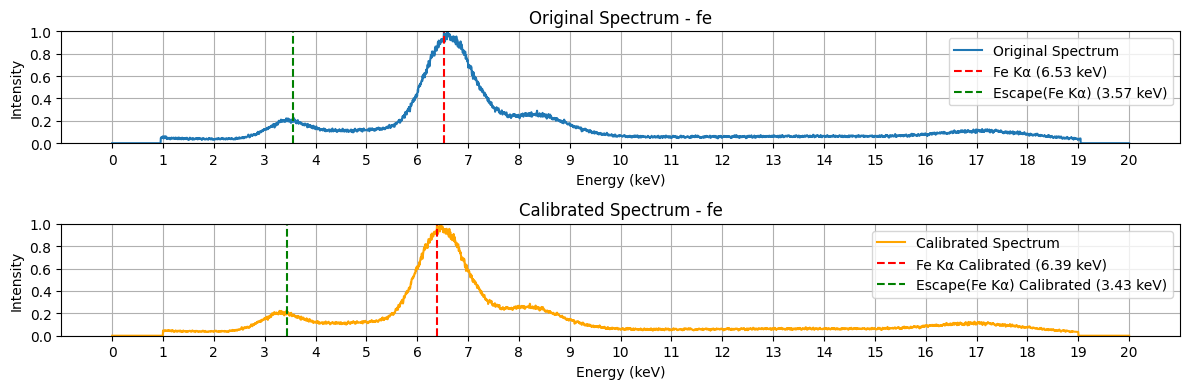

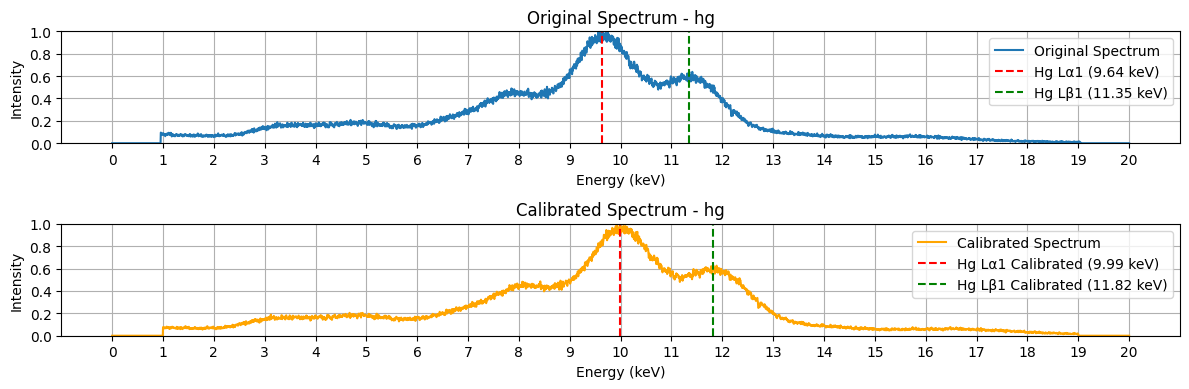

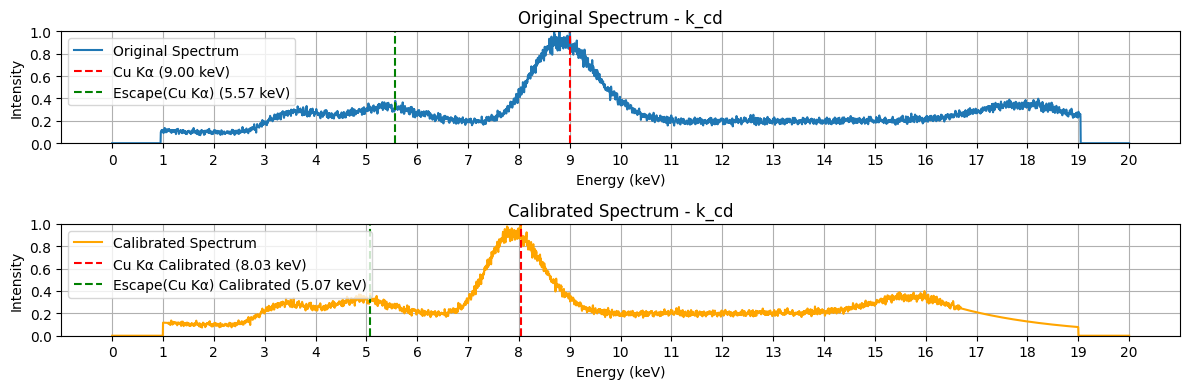

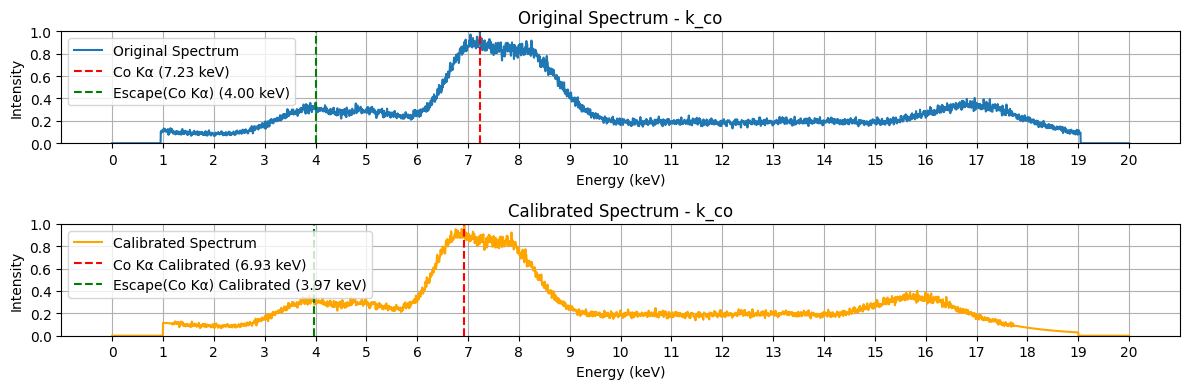

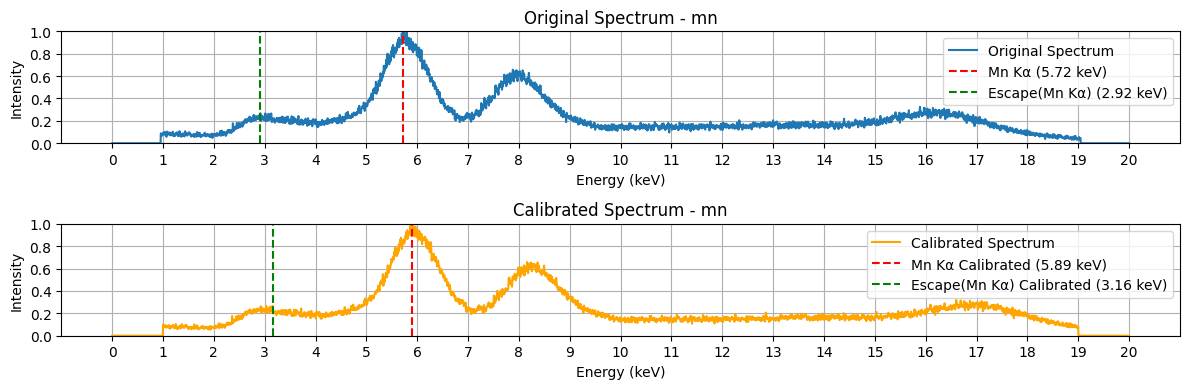

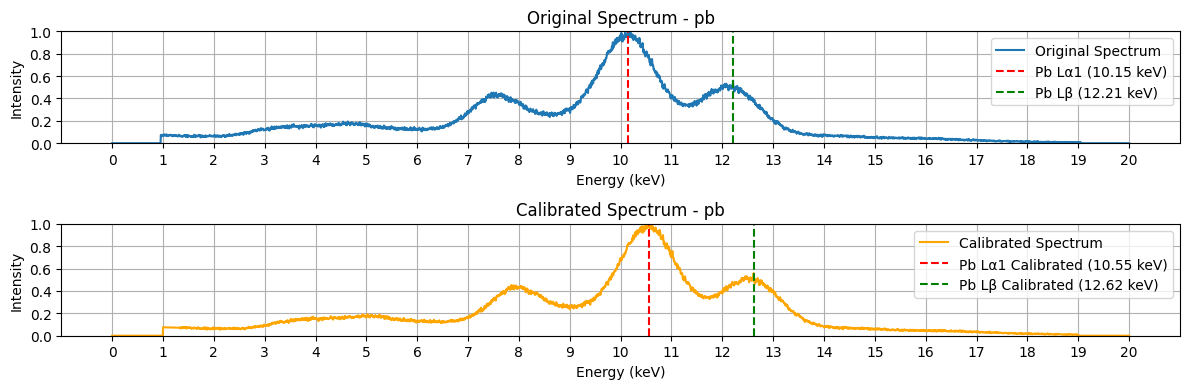

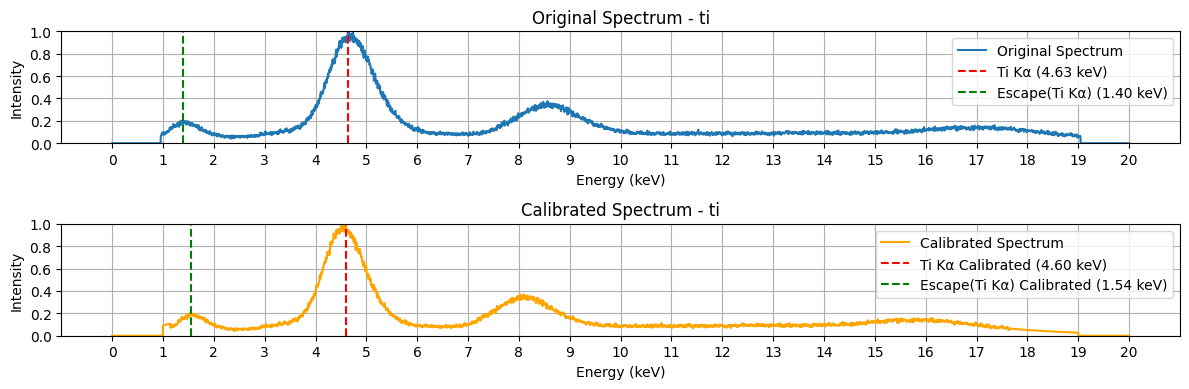

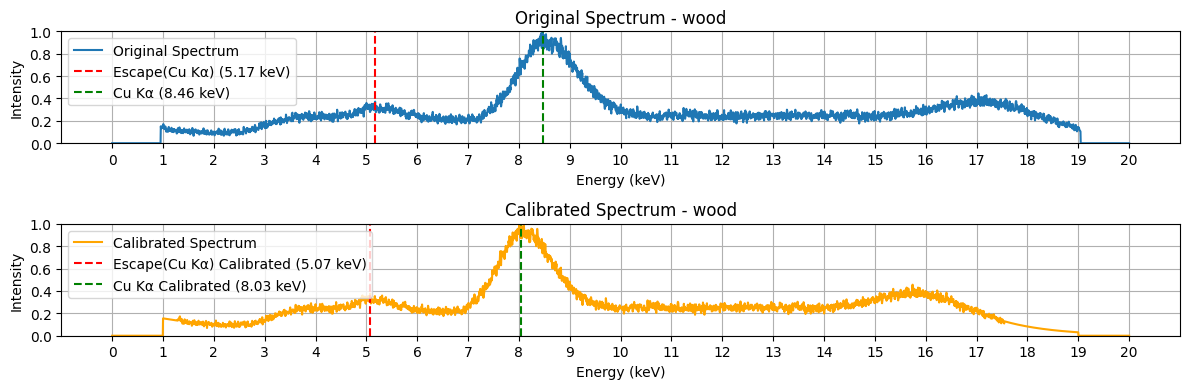

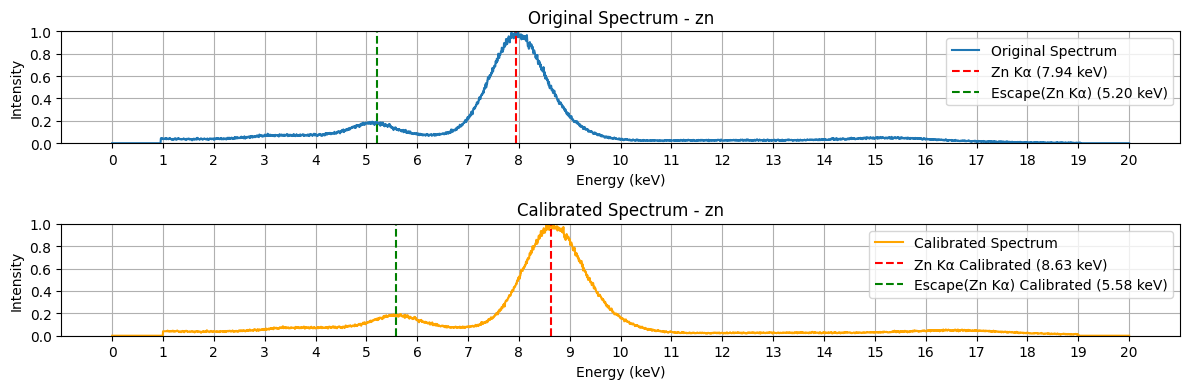

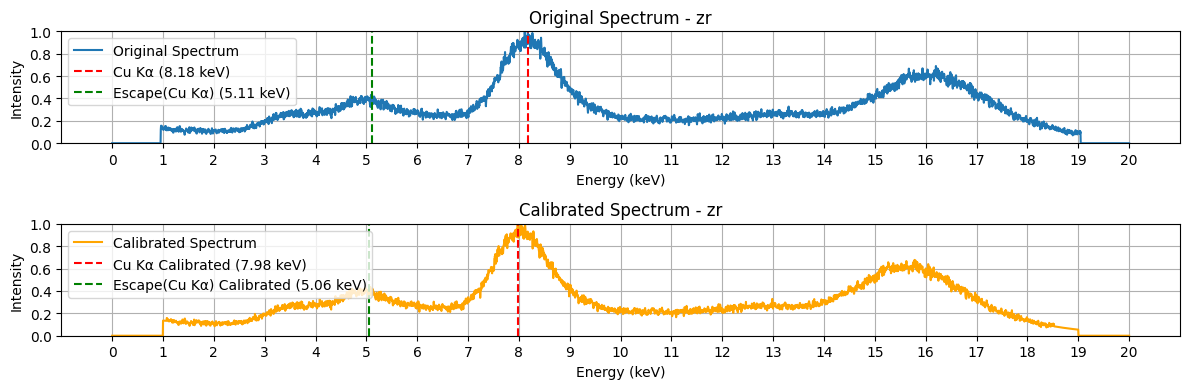

In [2]:
from src.DataPreprocessor import DataPreprocessor
from src.Elements import Elements

# Define peak finder functions for different materials
def cu_wood_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    escape_peak = np.argmax(spectrum[:max(0, main_peak - 400)])
    return [escape_peak, main_peak]

def hg_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[main_peak + 300:]) + main_peak + 300
    return [main_peak, second_peak]

def ca_zn_pb_peak_finder(spectrum):
    main_peak = np.argmax(spectrum[2000:]) + 2000
    second_peak = np.argmax(spectrum[main_peak + 300:]) + main_peak + 300
    return [main_peak, second_peak]

def pb_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[main_peak + 300:]) + main_peak + 300
    return [main_peak, second_peak]

def ca_zn_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def as_ca_zn_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def mn_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def cr_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def ti_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def as_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def zr_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def fe_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def k_cd_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def k_co_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def zn_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def co_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def ba_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def au_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[main_peak + 300:]) + main_peak + 300
    return [main_peak, second_peak]

# Configuration for each material defining how to process and plot
pad_configs = {
    "cu": {
        "peak_finder": cu_wood_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cu",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cu Kα)"
            },
            {
                "element": "cu",
                "line": "k_alpha",
                "label": "Cu Kα"
            }
        ]
    },
    "wood": {
        "peak_finder": cu_wood_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cu",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cu Kα)"
            },
            {
                "element": "cu",
                "line": "k_alpha",
                "label": "Cu Kα"
            }
        ]
    },
    "hg": {
        "peak_finder": hg_peak_finder,
        "peaks_energy_info": [
            {
                "element": "hg",
                "line": "l_alpha1",
                "label": "Hg Lα1"
            },
            {
                "element": "hg",
                "line": "l_beta1",
                "label": "Hg Lβ1"
            }
        ]
    },
    "ca_zn_pb": {
        "peak_finder": ca_zn_pb_peak_finder,
        "peaks_energy_info": [
            {
                "element": "pb",
                "line": "l_alpha1",
                "label": "Pb Lα1"
            },
            {
                "element": "pb",
                "line": "l_beta",
                "label": "Pb Lβ"
            }
        ]
    },
    "pb": {
        "peak_finder": pb_peak_finder,
        "peaks_energy_info": [
            {
                "element": "pb",
                "line": "l_alpha1",
                "label": "Pb Lα1"
            },
            {
                "element": "pb",
                "line": "l_beta",
                "label": "Pb Lβ"
            }
        ]
    },
    "ca_zn": {
        "peak_finder": ca_zn_peak_finder,
        "peaks_energy_info": [
            {
                "element": "zn",
                "line": "k_alpha",
                "label": "Zn Kα"
            },
            {
                "element": "zn",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Zn Kα)"
            },
        ]
    },
    "as_ca_zn": {
        "peak_finder": as_ca_zn_peak_finder,
        "peaks_energy_info": [
            {
                "element": "as",
                "line": "k_alpha",
                "label": "As Kα"
            },
            {
                "element": "as",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(As Kα)"
            }
        ]
    },
    "mn": {
        "peak_finder": mn_peak_finder,
        "peaks_energy_info": [
            {
                "element": "mn",
                "line": "k_alpha",
                "label": "Mn Kα"
            },
            {
                "element": "mn",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Mn Kα)"
            }
        ]
    },
    "cr": {
        "peak_finder": cr_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cr",
                "line": "k_alpha",
                "label": "Cr Kα"
            },
            {
                "element": "cr",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cr Kα)"
            }
        ]
    },
    "ti": {
        "peak_finder": ti_peak_finder,
        "peaks_energy_info": [
            {
                "element": "ti",
                "line": "k_alpha",
                "label": "Ti Kα"
            },
            {
                "element": "ti",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Ti Kα)"
            }
        ]
    },
    "as": {
        "peak_finder": as_peak_finder,
        "peaks_energy_info": [
            {
                "element": "as",
                "line": "k_alpha",
                "label": "As Kα"
            },
            {
                "element": "as",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(As Kα)"
            }
        ]
    },
    "zr": {
        "peak_finder": zr_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cu",
                "line": "k_alpha",
                "label": "Cu Kα"
            },
            {
                "element": "cu",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cu Kα)"
            }
        ]
    },
    "fe": {
        "peak_finder": fe_peak_finder,
        "peaks_energy_info": [
            {
                "element": "fe",
                "line": "k_alpha",
                "label": "Fe Kα"
            },
            {
                "element": "fe",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Fe Kα)"
            }
        ]
    },
    "k_cd": {
        "peak_finder": k_cd_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cu",
                "line": "k_alpha",
                "label": "Cu Kα"
            },
            {
                "element": "cu",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cu Kα)"
            }
        ]
    },
    "k_co": {
        "peak_finder": k_co_peak_finder,
        "peaks_energy_info": [
            {
                "element": "co",
                "line": "k_alpha",
                "label": "Co Kα"
            },
            {
                "element": "co",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Co Kα)"
            }
        ]
    },
    "zn": {
        "peak_finder": zn_peak_finder,
        "peaks_energy_info": [
            {
                "element": "zn",
                "line": "k_alpha",
                "label": "Zn Kα"
            },
            {
                "element": "zn",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Zn Kα)"
            }
        ]
    },
    "co": {
        "peak_finder": co_peak_finder,
        "peaks_energy_info": [
            {
                "element": "co",
                "line": "k_alpha",
                "label": "Co Kα"
            },
            {
                "element": "co",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Co Kα)"
            }
        ]
    },
    "ba": {
        "peak_finder": ba_peak_finder,
        "peaks_energy_info": [
            {
                "element": "ba",
                "line": "l_alpha",
                "label": "Ba Lα"
            },
            {
                "element": "ba",
                "line": "l_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Ba Lα)"
            }
        ]
    },
    "au": {
        "peak_finder": au_peak_finder,
        "peaks_energy_info": [
            {
                "element": "au",
                "line": "l_alpha",
                "label": "Au Lα"
            },
            {
                "element": "au",
                "line": "l_beta",
                "label": "Au Lβ"
            }
        ]
    }
}

def calibrate_and_plot_spectrum(pad_name, spectrum):
    config = pad_configs.get(pad_name)
    if not config:
        return None  # Skip unknown materials
    
    peak_finder = config["peak_finder"]
    peaks_energy_info = config["peaks_energy_info"]
    
    # Detect peaks in original spectrum
    original_peaks = peak_finder(spectrum)
    
    # Calculate theoretical energies for each peak
    energies = []
    original_labels = []
    for peak_info in peaks_energy_info:
        element = peak_info["element"]
        line = peak_info["line"]
        energy = Elements.get_element_line_energy(element, line)
        if "energy_offset" in peak_info:
            energy += peak_info["energy_offset"]
        energies.append(energy)
        original_labels.append(peak_info["label"])
    
    # Process the spectrum
    energy_axis, processed_spectrum = DataPreprocessor.processed_spectrum(spectrum, original_peaks, energies)
    
    # Detect peaks in Calibrated spectrum
    Calibrated_peaks = peak_finder(processed_spectrum)
    Calibrated_labels = [f"{label} Calibrated" for label in original_labels]
    
    # Create plots
    fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=False)
    colors = ['r', 'g', 'm', 'c']
    
    # Plot original spectrum
    axs[0].plot(energy_axis, spectrum, label="Original Spectrum")
    for i, (pos, label) in enumerate(zip(original_peaks, original_labels)):
        axs[0].axvline(energy_axis[pos], color=colors[i], linestyle='--', 
                        label=f"{label} ({energy_axis[pos]:.2f} keV)")
    axs[0].set_title(f"Original Spectrum - {pad_name}")
    axs[0].legend()
    axs[0].set_xticks(np.arange(0, 21))
    axs[0].set_yticks(np.arange(0, 1.1, 0.2))
    axs[0].grid(True)
    axs[0].set_ylim(0, 1)  # Adjust based on normalization
    axs[0].set_xlabel("Energy (keV)")
    axs[0].set_ylabel("Intensity")
    
    # Plot Calibrated spectrum
    axs[1].plot(energy_axis, processed_spectrum, color='orange', label="Calibrated Spectrum")
    for i, (pos, label) in enumerate(zip(Calibrated_peaks, Calibrated_labels)):
        axs[1].axvline(energy_axis[pos], color=colors[i], linestyle='--', 
                        label=f"{label} ({energy_axis[pos]:.2f} keV)")
    axs[1].set_title(f"Calibrated Spectrum - {pad_name}")
    axs[1].legend()
    axs[1].set_xticks(np.arange(0, 21))
    axs[1].set_yticks(np.arange(0, 1.1, 0.2))
    axs[1].grid(True)
    axs[1].set_ylim(0, 1)  # Adjust based on normalization
    axs[1].set_xlabel("Energy (keV)")
    axs[1].set_ylabel("Intensity")
    
    plt.xlabel("Energy (keV)")
    plt.tight_layout()
    plt.show()

    return processed_spectrum

calibrated_spectra = {}

# Iterate over spectra dictionary
for pad_name, spectrum in sorted(spectra.items()):
    calibrated_spectrum = calibrate_and_plot_spectrum(pad_name, spectrum)
    if calibrated_spectrum is not None:
        calibrated_spectra[pad_name] = calibrated_spectrum

17
17


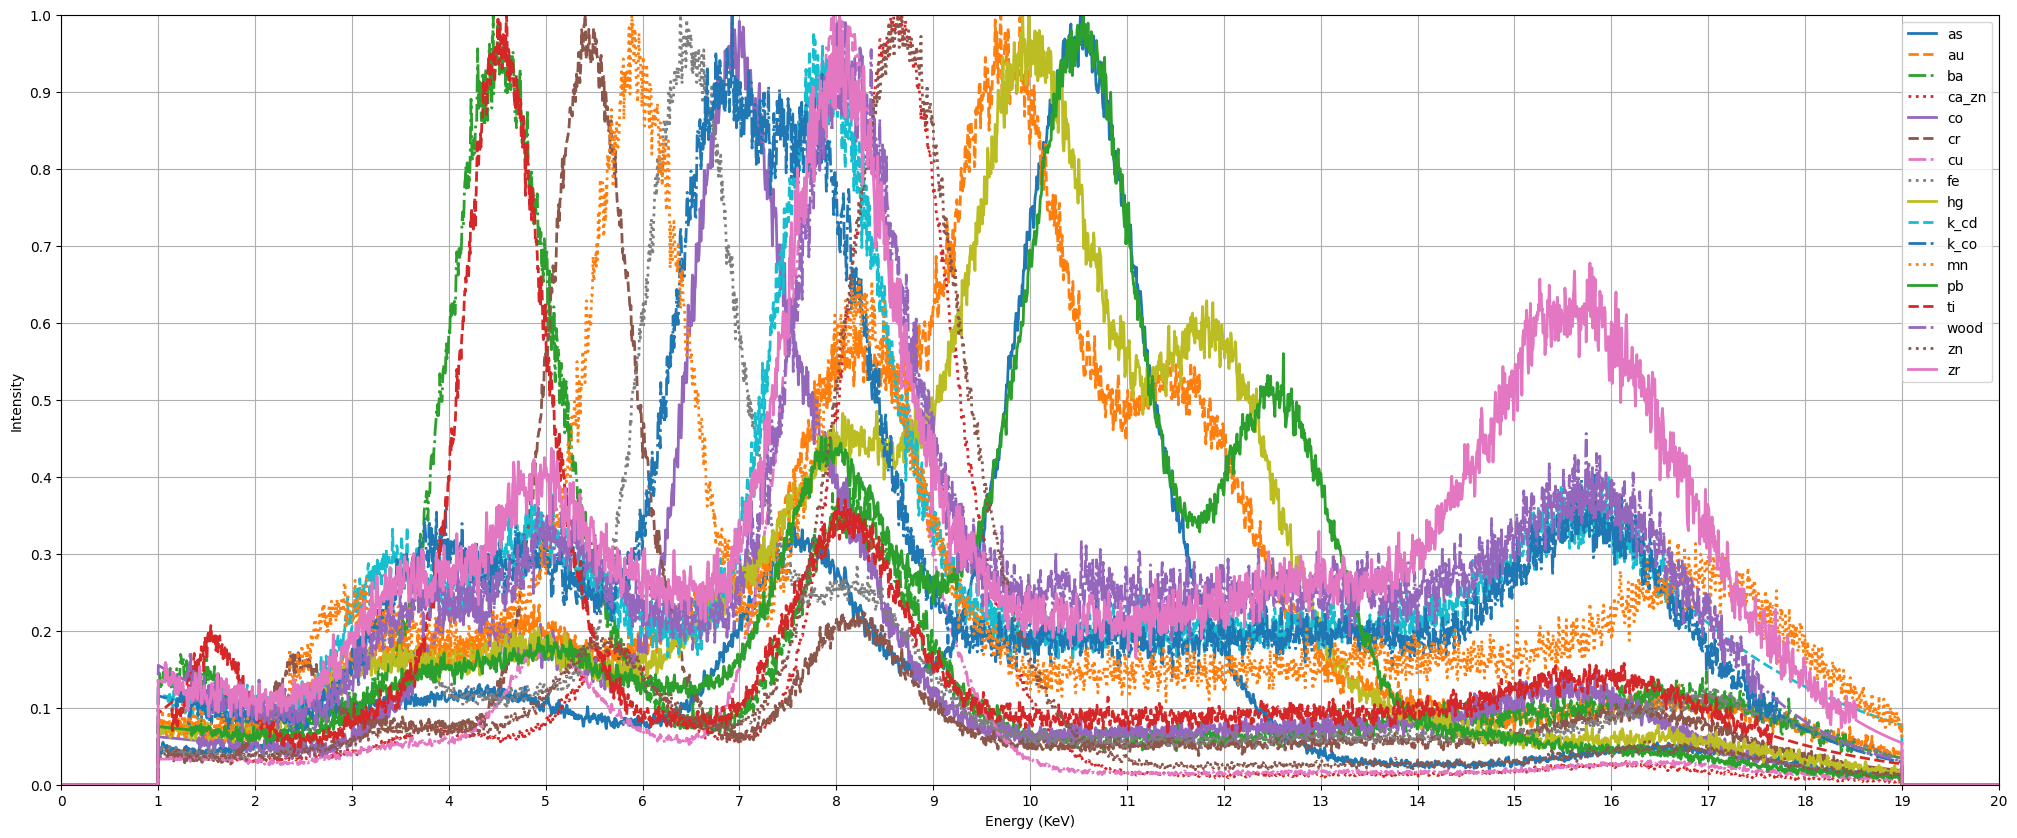

In [3]:
line_styles = ['-', '--', '-.', ':']
plt.figure(figsize=(25, 10))
print(len(calibrated_spectra))
print(len(spectra))
for (pad_name, spectrum), linestyle in zip(
    calibrated_spectra.items(), itertools.cycle(line_styles)
):

    plt.plot(np.linspace(0, 20, 4096),spectrum, linestyle=linestyle, label=pad_name, linewidth=2)
    plt.set_cmap("tab10")

plt.legend()
plt.ylim(0, 1)
plt.xlim(0, 20)
plt.grid(True)
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel("Energy (KeV)")
plt.ylabel("Intensity")
plt.show()

/tmp/ipykernel_692646/1072518864.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(-1.0, 1.0)

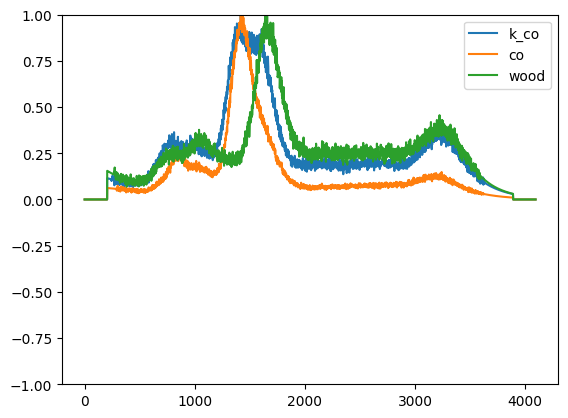

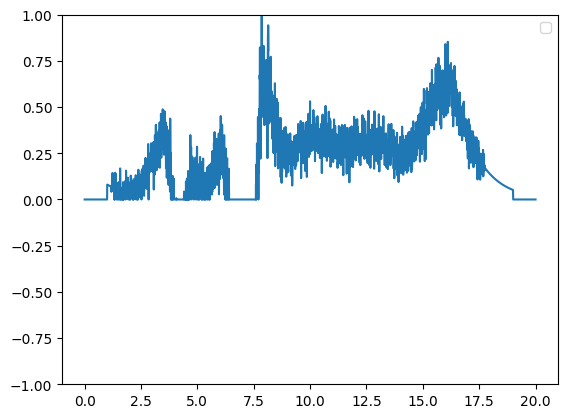

In [4]:

def bisect_subtract_residual(a: np.ndarray, b: np.ndarray, target_fraction: float = 0.1, tol: float = 0.01, max_iter: int = 1000) -> np.ndarray:
    """
    Subtracts spectrum `b` from `a` using bisection until `target_fraction` of resulting values are negative.
    
    Parameters:
        a (np.ndarray): Original spectrum.
        b (np.ndarray): Spectrum to subtract (residual).
        target_fraction (float): Target fraction of negative values in the result.
        tol (float): Tolerance for stopping the bisection.
        max_iter (int): Maximum number of iterations.
    
    Returns:
        np.ndarray: Adjusted spectrum after subtraction.
    """
    if a.shape != b.shape:
        raise ValueError("Spectra `a` and `b` must have the same shape.")
    
    # Initial bounds for scaling factor alpha
    alpha_low, alpha_high = 0.0, (np.max(a) / np.max(b) + 1e-9) * 2
    
    for _ in range(max_iter):
        alpha = (alpha_low + alpha_high) / 2
        result = a - alpha * b
        negative_fraction = np.mean(result < 0)
        
        if abs(negative_fraction - target_fraction) < tol:
            break
        elif negative_fraction > target_fraction:
            alpha_high = alpha
        else:
            alpha_low = alpha
            
    result[result < 0] = 0
    result = result / np.max(result)
    return result

plt.figure(1)
plt.plot(calibrated_spectra["k_co"], label="k_co")
plt.plot(calibrated_spectra["co"], label="co")
plt.plot(calibrated_spectra["wood"], label="wood")
plt.legend()
plt.ylim(-1, 1)

plt.figure(2)
res = bisect_subtract_residual(calibrated_spectra["k_co"], calibrated_spectra["co"], target_fraction=0.1)
plt.plot(np.linspace(0, 20, len(res)), res)

plt.legend()
plt.ylim(-1, 1)

(-1.0, 1.0)

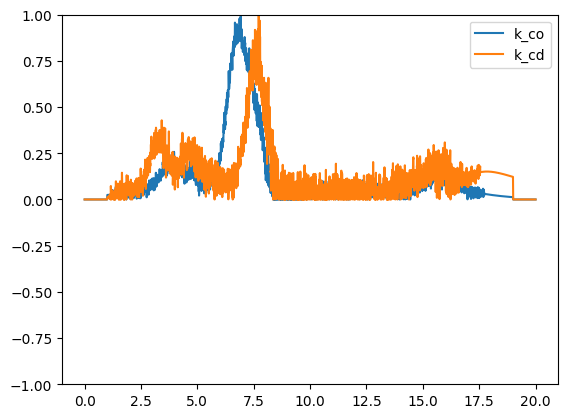

In [5]:
k_co = bisect_subtract_residual(calibrated_spectra["k_co"], calibrated_spectra["wood"], target_fraction=0.05)
k_cd = bisect_subtract_residual(calibrated_spectra["k_cd"], calibrated_spectra["wood"], target_fraction=0.05)
plt.plot(np.linspace(0, 20, 4096), k_co, label="k_co")
plt.plot(np.linspace(0, 20, 4096), k_cd, label="k_cd")
plt.legend()
plt.ylim(-1, 1)